# CSCI 611 — Assignment 3: Small-object traffic detection (YOLOv8)

Structured as **config + helpers**, not as a line duplicate of any reference notebook.

### Assignment ↔ notebook map
| Course ask | Section |
|------------|---------|
| Pretrained YOLO + test evaluation | Part C |
| YOLO-format dataset | Part B |
| Fine-tune, resolution, augmentation | Part D |
| Compare pretrained vs fine-tuned | Part E |
| NMS / confidence tuning | Part F |
| Video or frames, conf ≥ 0.5 | Part G |
| Figures / tables / LaTeX bundle | Part H |

Default data matches **refer_assignment3.ipynb**: [Traffic Sign Detection YOLOv8 (TU Wien)](https://universe.roboflow.com/tu-wien-pfowz/traffic-sign-detection-yolov8). Edit `RUN_CFG["roboflow"]` to use another Universe project.


## Part A — Dependencies

Use a **GPU** for training. SciPy improves the interpolated NMS figure in Part H.


In [1]:
%pip install -q ultralytics opencv-python matplotlib pandas pyyaml roboflow tqdm scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.4 MB/s eta 0:00:00


In [2]:
import os
import random
import yaml
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from ultralytics import YOLO

ARTIFACT_ROOT = Path("csci611_a3_work")
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_CFG = {
    "seed": 42,
    "baseline_imgsz": 640,
    "train_imgsz": 1280,
    "epochs": 40,
    "batch": 12,
    "patience": 14,
    "workers": 4,
    "val_conf": 0.25,
    "val_iou": 0.50,
    "roboflow": {
        "workspace": "tu-wien-pfowz",
        "project": "traffic-sign-detection-yolov8",
        "version": 9,
    },
    "names": {
        "pretrained_val": "01_eval_pretrained_test",
        "pretrained_pred": "02_visual_pretrained",
        "train_job": "03_train_finetune",
        "finetuned_pred": "04_visual_finetuned",
    },
}

random.seed(RUN_CFG["seed"])
np.random.seed(RUN_CFG["seed"])


def runs_detect_alias(name: str) -> Path:
    return Path("runs/detect") / ARTIFACT_ROOT.name / name


def first_existing_dir(*paths: Path) -> Path:
    for p in paths:
        if p.is_dir():
            return p
    return Path(paths[0])


def tally_images(folder) -> int:
    root = Path(folder)
    return sum(len(list(root.glob(p))) for p in ("*.jpg", "*.jpeg", "*.png", "*.bmp"))


def metric_record(tag: str, res, imgsz: int) -> dict:
    return {
        f"{tag}_imgsz": imgsz,
        f"{tag}_mAP50": float(res.box.map50),
        f"{tag}_mAP5095": float(res.box.map),
        f"{tag}_precision": float(res.box.mp),
        f"{tag}_recall": float(res.box.mr),
    }


def mosaic_from_predictions(pred_slug: str, suptitle: str, max_cells: int = 6):
    folder = first_existing_dir(ARTIFACT_ROOT / pred_slug, runs_detect_alias(pred_slug))
    files = sorted(folder.glob("*.jpg"))[:max_cells] or sorted(folder.glob("*.png"))[:max_cells]
    if not files:
        print("No images in", folder)
        return
    n_cols = 3
    n_rows = int(np.ceil(len(files) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.1 * n_cols, 3.3 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, fp in zip(axes, files):
        bgr = cv2.imread(str(fp))
        if bgr is None:
            continue
        ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        ax.axis("off")
    for ax in axes[len(files) :]:
        ax.axis("off")
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


print("Ready — ARTIFACT_ROOT:", ARTIFACT_ROOT.resolve())


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ready — ARTIFACT_ROOT: /content/csci611_a3_work


## Part B — Dataset

- **API:** paste your key into `RF_KEY_INLINE` in the next cell (same idea as the reference notebook), **or** `export ROBOFLOW_API_KEY='...'` / Colab Secrets. Leave `MANUAL_ROOT = None`.
- **Zip:** Download **YOLOv8** from Roboflow → unzip → `MANUAL_ROOT = Path("...")` (folder with `data.yaml` + `train`/`valid`/`test`).
- **Public GitHub:** remove/rotate any inline key before pushing.


In [3]:
# Assignment convenience: paste your Roboflow private key here (like refer_assignment3.ipynb).
# Prefer env var for shared repos: export ROBOFLOW_API_KEY='...'
# Remove this string before pushing to public GitHub.
RF_KEY_INLINE = "zGO2oHWPQgPnkcoFnRun"  # from refer_assignment3.ipynb — rotate on Roboflow if repo is public

MANUAL_ROOT = None  # Path("./traffic-sign-detection-yolov8-9")  # after manual YOLOv8 zip unzip

if MANUAL_ROOT is not None:
    DATASET_ROOT = Path(MANUAL_ROOT).resolve()
    if not DATASET_ROOT.is_dir():
        raise FileNotFoundError(DATASET_ROOT)
else:
    from roboflow import Roboflow
    key = (os.environ.get("ROBOFLOW_API_KEY") or RF_KEY_INLINE or "").strip()
    if not key:
        raise RuntimeError("Paste RF_KEY_INLINE in this cell, set env ROBOFLOW_API_KEY, or set MANUAL_ROOT.")
    rf_cfg = RUN_CFG["roboflow"]
    blob = (
        Roboflow(api_key=key)
        .workspace(rf_cfg["workspace"])
        .project(rf_cfg["project"])
        .version(rf_cfg["version"])
        .download("yolov8")
    )
    DATASET_ROOT = Path(blob.location).resolve()

print("DATASET_ROOT:", DATASET_ROOT)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to traffic-sign-detection-yolov8-9 in yolov8:: 100%|██████████| 3068/3068 [00:00<00:00, 3824.81it/s]


DATASET_ROOT: /content/traffic-sign-detection-yolov8-9


In [6]:
cands = sorted(DATASET_ROOT.glob("*.yaml"))
if not cands:
    cands = sorted(DATASET_ROOT.rglob("data.yaml"))
if not cands:
    raise FileNotFoundError(DATASET_ROOT)

with open(cands[0], "r", encoding="utf-8") as fh:
    cfg = yaml.safe_load(fh)

cfg["train"] = str(DATASET_ROOT / "train" / "images")
cfg["val"] = str(DATASET_ROOT / "valid" / "images")
cfg["test"] = str(DATASET_ROOT / "test" / "images")

DATA_YAML = ARTIFACT_ROOT / "dataset_csci611.yaml"
DATA_YAML.write_text(yaml.dump(cfg, sort_keys=False), encoding="utf-8")
DATA_YAML_STR = str(DATA_YAML.resolve())
print("Using template:", cands[0])
print("Emitting:", DATA_YAML_STR)
print(yaml.dump(cfg, default_flow_style=False))


Using template: /content/traffic-sign-detection-yolov8-9/data.yaml
Emitting: /content/csci611_a3_work/dataset_csci611.yaml
names:
- traffic-signs
nc: 1
roboflow:
  license: MIT
  project: traffic-sign-detection-yolov8
  url: https://universe.roboflow.com/tu-wien-pfowz/traffic-sign-detection-yolov8/dataset/9
  version: 9
  workspace: tu-wien-pfowz
test: /content/traffic-sign-detection-yolov8-9/test/images
train: /content/traffic-sign-detection-yolov8-9/train/images
val: /content/traffic-sign-detection-yolov8-9/valid/images



In [7]:
display(pd.DataFrame([{"split": k, "n_images": tally_images(cfg[k])} for k in ("train", "val", "test")]))


,split,n_images
0,train,1182
1,val,196
2,test,150


Roboflow’s split is fixed. For a *random* 10–15% test pool you’d re-partition files and rewrite this yaml (state in the report).


## Part C — Pretrained COCO baseline on **test**


In [8]:
model_id = "yolov8n.pt"
pretrained = YOLO(model_id)

m_pretrained = pretrained.val(
    data=DATA_YAML_STR,
    split="test",
    imgsz=RUN_CFG["baseline_imgsz"],
    conf=RUN_CFG["val_conf"],
    iou=RUN_CFG["val_iou"],
    project=str(ARTIFACT_ROOT),
    name=RUN_CFG["names"]["pretrained_val"],
)
print(metric_record("pt", m_pretrained, RUN_CFG["baseline_imgsz"]))


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1010.0±477.1 MB/s, size: 37.2 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 1.7Kit/s 0.1s
val: New cache created: /content/traffic-sign-detection-yolov8-9/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 2.4it/s 4.2s
                   all        150        218     0.0281    0.00459     0.0105     0.0021
                person        150        218     0.0281    0.00459     0.0105     0.0021
Speed: 4.3ms preprocess, 5.6ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to /content/runs/detect/csci611_a3_work/01_eval_pretrained_test
{'pt_imgsz': 640, 'pt_mAP50': 0.010507081865004065, 'pt

In [9]:
pretrained.predict(
    source=cfg["test"],
    imgsz=RUN_CFG["baseline_imgsz"],
    conf=RUN_CFG["val_conf"],
    iou=RUN_CFG["val_iou"],
    save=True,
    project=str(ARTIFACT_ROOT),
    name=RUN_CFG["names"]["pretrained_pred"],
    exist_ok=True,
)



image 1/150 /content/traffic-sign-detection-yolov8-9/test/images/00217_jpg.rf.ba5ade3eafba67712065486fecb5483c.jpg: 480x640 10 cars, 44.3ms
image 2/150 /content/traffic-sign-detection-yolov8-9/test/images/00318_jpg.rf.bcdd29521712c84a2ace989c390bda35.jpg: 480x640 (no detections), 6.7ms
image 3/150 /content/traffic-sign-detection-yolov8-9/test/images/00355_jpg.rf.c1a2f426e05f952833b0f544ed8f8cc8.jpg: 480x640 4 cars, 2 trucks, 6.1ms
image 4/150 /content/traffic-sign-detection-yolov8-9/test/images/00362_jpg.rf.f0ae1e0ae6a86b49c5cfa765557e9116.jpg: 480x640 5 cars, 2 trucks, 6.2ms
image 5/150 /content/traffic-sign-detection-yolov8-9/test/images/00367_jpg.rf.c0aa01d8979c786385c3f1ddbb62fc2f.jpg: 480x640 4 cars, 6.3ms
image 6/150 /content/traffic-sign-detection-yolov8-9/test/images/00370_jpg.rf.ae5066be5aaadd4efb41aa4073565fb8.jpg: 480x640 4 cars, 6.6ms
image 7/150 /content/traffic-sign-detection-yolov8-9/test/images/00378_jpg.rf.990ec0282b922ae6870409b3eadcf3a6.jpg: 480x640 4 cars, 6.5ms
im

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

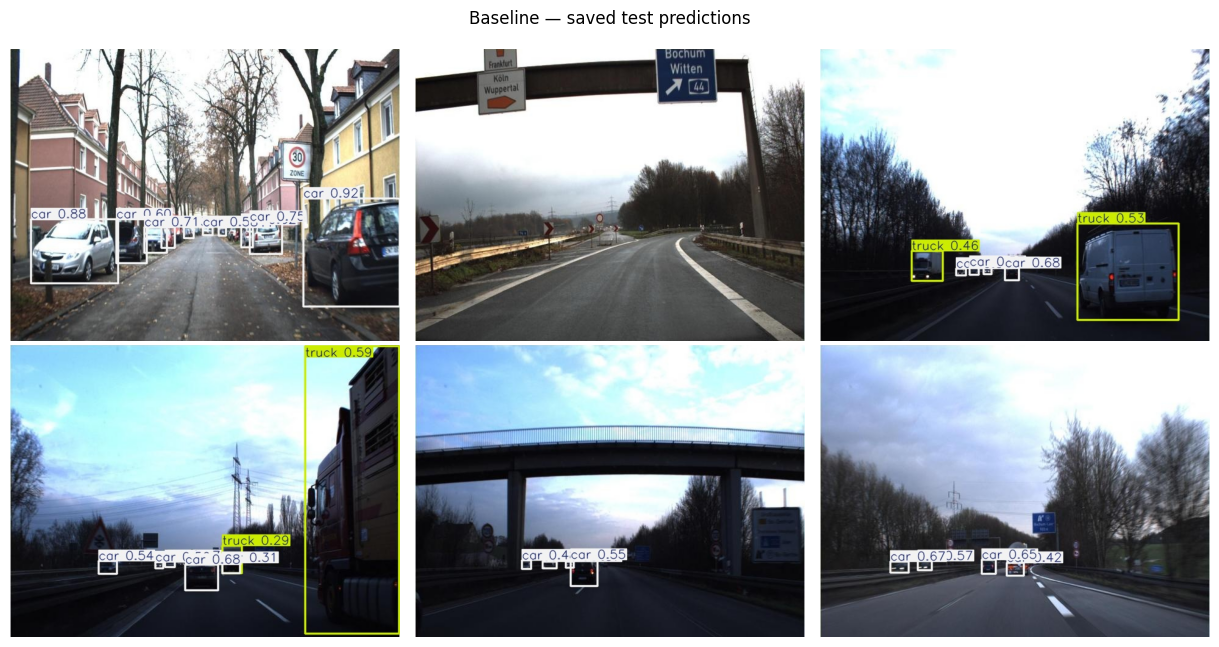

In [10]:
mosaic_from_predictions(RUN_CFG["names"]["pretrained_pred"], "Baseline — saved test predictions")


## Part D — Fine-tuning (high `imgsz`, custom aug)


In [11]:
student = YOLO(model_id)
history = student.train(
    data=DATA_YAML_STR,
    epochs=RUN_CFG["epochs"],
    imgsz=RUN_CFG["train_imgsz"],
    batch=RUN_CFG["batch"],
    patience=RUN_CFG["patience"],
    workers=RUN_CFG["workers"],
    project=str(ARTIFACT_ROOT),
    name=RUN_CFG["names"]["train_job"],
    exist_ok=True,
    optimizer="auto",
    hsv_h=0.015,
    hsv_s=0.65,
    hsv_v=0.35,
    degrees=8.0,
    translate=0.12,
    scale=0.55,
    fliplr=0.5,
    mosaic=0.95,
    mixup=0.08,
    close_mosaic=12,
)

save_dir = getattr(history, "save_dir", None) or (history.get("save_dir") if isinstance(history, dict) else None)
if save_dir is None:
    save_dir = ARTIFACT_ROOT / RUN_CFG["names"]["train_job"]
weights_best = Path(save_dir) / "weights" / "best.pt"
assert weights_best.is_file(), weights_best
print("best.pt:", weights_best)


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=12, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/csci611_a3_work/dataset_csci611.yaml, degrees=8.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.65, hsv_v=0.35, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.08, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.95, multi_scale=0.0, name=03_train_finetune, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

### Inference resolution sweep (same `best.pt`)


In [12]:
specialist = YOLO(str(weights_best))

res_bits = []
for iz in (RUN_CFG["baseline_imgsz"], RUN_CFG["train_imgsz"]):
    mv = specialist.val(
        data=DATA_YAML_STR,
        split="test",
        imgsz=iz,
        conf=RUN_CFG["val_conf"],
        iou=RUN_CFG["val_iou"],
        project=str(ARTIFACT_ROOT),
        name=f"05_res_{iz}",
        verbose=False,
    )
    res_bits.append({"inference_imgsz": iz, "mAP50": float(mv.box.map50), "mAP50-95": float(mv.box.map), "Precision": float(mv.box.mp), "Recall": float(mv.box.mr)})

res_df = pd.DataFrame(res_bits)
display(res_df)
res_df.to_csv(ARTIFACT_ROOT / "resolution_inference_ablation.csv", index=False)

m_specialist = specialist.val(
    data=DATA_YAML_STR,
    split="test",
    imgsz=RUN_CFG["train_imgsz"],
    conf=RUN_CFG["val_conf"],
    iou=RUN_CFG["val_iou"],
    project=str(ARTIFACT_ROOT),
    name="06_eval_finetuned_primary",
)
print(metric_record("ft", m_specialist, RUN_CFG["train_imgsz"]))


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1042.1±475.8 MB/s, size: 38.3 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 41.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.2it/s 3.1s
                   all        150        218      0.954      0.835      0.919       0.62
Speed: 3.5ms preprocess, 3.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/csci611_a3_work/05_res_640
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1180.9±671.8 MB/s, size: 45.8 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.c

,inference_imgsz,mAP50,mAP50-95,Precision,Recall
0,640,0.918512,0.619532,0.954171,0.834862
1,1280,0.969293,0.680066,0.950345,0.935780


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1048.8±300.0 MB/s, size: 43.0 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 48.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.6it/s 6.2s
                   all        150        218       0.95      0.936      0.969       0.68
Speed: 10.8ms preprocess, 12.5ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /content/runs/detect/csci611_a3_work/06_eval_finetuned_primary
{'ft_imgsz': 1280, 'ft_mAP50': 0.9692932212320812, 'ft_mAP5095': 0.6800664105246657, 'ft_precision': 0.9503447301358096, 'ft_recall': 0.9357798165137615}


In [13]:
specialist.predict(
    source=cfg["test"],
    imgsz=RUN_CFG["train_imgsz"],
    conf=RUN_CFG["val_conf"],
    iou=RUN_CFG["val_iou"],
    save=True,
    project=str(ARTIFACT_ROOT),
    name=RUN_CFG["names"]["finetuned_pred"],
    exist_ok=True,
)



image 1/150 /content/traffic-sign-detection-yolov8-9/test/images/00217_jpg.rf.ba5ade3eafba67712065486fecb5483c.jpg: 960x1280 1 traffic-signs, 36.8ms
image 2/150 /content/traffic-sign-detection-yolov8-9/test/images/00318_jpg.rf.bcdd29521712c84a2ace989c390bda35.jpg: 960x1280 1 traffic-signs, 14.8ms
image 3/150 /content/traffic-sign-detection-yolov8-9/test/images/00355_jpg.rf.c1a2f426e05f952833b0f544ed8f8cc8.jpg: 960x1280 1 traffic-signs, 14.8ms
image 4/150 /content/traffic-sign-detection-yolov8-9/test/images/00362_jpg.rf.f0ae1e0ae6a86b49c5cfa765557e9116.jpg: 960x1280 1 traffic-signs, 14.8ms
image 5/150 /content/traffic-sign-detection-yolov8-9/test/images/00367_jpg.rf.c0aa01d8979c786385c3f1ddbb62fc2f.jpg: 960x1280 4 traffic-signss, 14.6ms
image 6/150 /content/traffic-sign-detection-yolov8-9/test/images/00370_jpg.rf.ae5066be5aaadd4efb41aa4073565fb8.jpg: 960x1280 4 traffic-signss, 13.3ms
image 7/150 /content/traffic-sign-detection-yolov8-9/test/images/00378_jpg.rf.990ec0282b922ae6870409b3e

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'traffic-signs'}
 obb: None
 orig_img: array([[[243, 255, 255],
         [223, 234, 238],
         [247, 251, 252],
         ...,
         [244, 255, 255],
         [221, 232, 229],
         [246, 255, 254]],
 
        [[208, 220, 226],
         [ 97, 108, 112],
         [ 77,  81,  82],
         ...,
         [ 90, 101,  99],
         [ 91, 102,  99],
         [210, 221, 218]],
 
        [[233, 245, 249],
         [ 52,  64,  66],
         [ 33,  38,  37],
         ...,
         [ 51,  59,  58],
         [ 56,  65,  62],
         [242, 251, 248]],
 
        ...,
 
        [[230, 237, 240],
         [ 43,  50,  53],
         [ 50,  55,  58],
         ...,
         [ 53,  55,  55],
         [ 48,  48,  48],
         [241, 242, 240]],
 
        [[235, 242, 245],
         [ 48,  55,  58],
         [ 53,  58,  61],
         ...,
         [ 

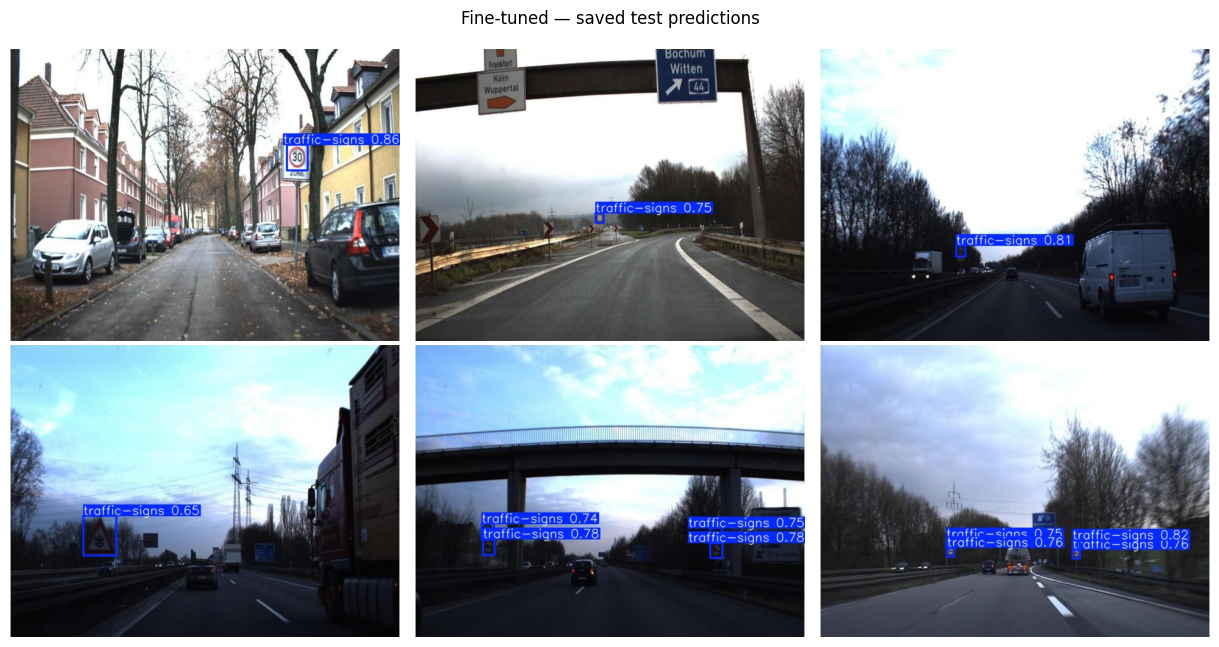

In [14]:
mosaic_from_predictions(RUN_CFG["names"]["finetuned_pred"], "Fine-tuned — saved test predictions")


## Part E — Quantitative comparison + reference-style CSVs


,stage,checkpoint,eval_imgsz,mAP50,mAP5095,precision,recall
0,pretrained_only,yolov8n.pt,640,0.010507,0.002101,0.028113,0.004587
1,finetuned_best,best.pt,1280,0.969293,0.680066,0.950345,0.935780


,Model,Image_Size,mAP50,mAP50-95,Precision,Recall
0,Pretrained YOLOv8n,640,0.010507,0.002101,0.028113,0.004587
1,Fine-tuned YOLOv8n,1280,0.969293,0.680066,0.950345,0.935780


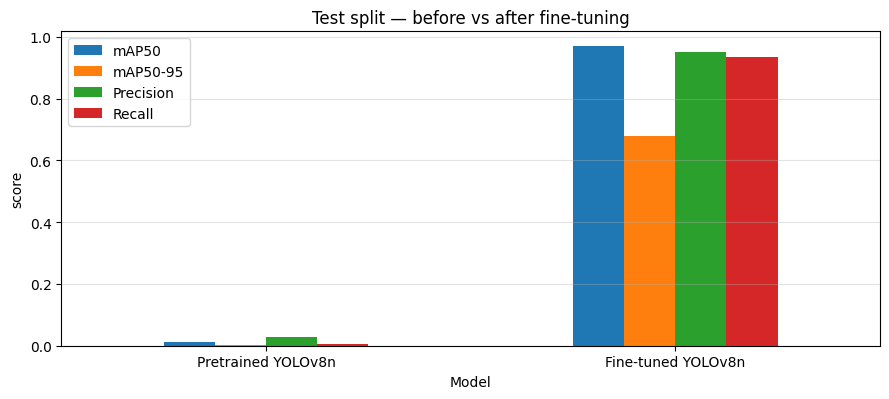

In [15]:
compare_rows = pd.DataFrame(
    [
        {
            "stage": "pretrained_only",
            "checkpoint": model_id,
            "eval_imgsz": RUN_CFG["baseline_imgsz"],
            "mAP50": float(m_pretrained.box.map50),
            "mAP5095": float(m_pretrained.box.map),
            "precision": float(m_pretrained.box.mp),
            "recall": float(m_pretrained.box.mr),
        },
        {
            "stage": "finetuned_best",
            "checkpoint": weights_best.name,
            "eval_imgsz": RUN_CFG["train_imgsz"],
            "mAP50": float(m_specialist.box.map50),
            "mAP5095": float(m_specialist.box.map),
            "precision": float(m_specialist.box.mp),
            "recall": float(m_specialist.box.mr),
        },
    ]
)
compare_rows.to_csv(ARTIFACT_ROOT / "pretrain_vs_finetune.csv", index=False)
display(compare_rows)

model_comparison = pd.DataFrame(
    [
        {
            "Model": "Pretrained YOLOv8n",
            "Image_Size": RUN_CFG["baseline_imgsz"],
            "mAP50": float(m_pretrained.box.map50),
            "mAP50-95": float(m_pretrained.box.map),
            "Precision": float(m_pretrained.box.mp),
            "Recall": float(m_pretrained.box.mr),
        },
        {
            "Model": "Fine-tuned YOLOv8n",
            "Image_Size": RUN_CFG["train_imgsz"],
            "mAP50": float(m_specialist.box.map50),
            "mAP50-95": float(m_specialist.box.map),
            "Precision": float(m_specialist.box.mp),
            "Recall": float(m_specialist.box.mr),
        },
    ]
)
model_comparison.to_csv(ARTIFACT_ROOT / "model_comparison.csv", index=False)
display(model_comparison)

model_comparison.set_index("Model")[["mAP50", "mAP50-95", "Precision", "Recall"]].plot.bar(
    figsize=(9, 4.1), title="Test split — before vs after fine-tuning", rot=0
)
plt.ylabel("score")
plt.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.show()


## Part F — Confidence & NMS IoU grid


In [16]:
combo = [(0.10, 0.40), (0.20, 0.50), (0.30, 0.55), (0.45, 0.65)]
records = []
for c_th, iou_th in combo:
    mr = specialist.val(
        data=DATA_YAML_STR,
        split="test",
        imgsz=RUN_CFG["train_imgsz"],
        conf=c_th,
        iou=iou_th,
        verbose=False,
    )
    records.append(
        {
            "confidence": c_th,
            "nms_iou": iou_th,
            "mAP50": float(mr.box.map50),
            "mAP50-95": float(mr.box.map),
            "Precision": float(mr.box.mp),
            "Recall": float(mr.box.mr),
        }
    )
tuning_frame = pd.DataFrame(records)
display(tuning_frame)
tuning_frame.to_csv(ARTIFACT_ROOT / "conf_nms_grid.csv", index=False)
tuning_frame.to_csv(ARTIFACT_ROOT / "confidence_nms_results.csv", index=False)


Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1985.3±447.3 MB/s, size: 56.8 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 48.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.4it/s 7.0s
                   all        150        218       0.95      0.936       0.98      0.685
Speed: 14.1ms preprocess, 12.5ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1482.1±524.7 MB/s, size: 48.8 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 62.9Mit/s 0.0s
              

,confidence,nms_iou,mAP50,mAP50-95,Precision,Recall
0,0.10,0.40,0.980198,0.684651,0.950345,0.93578
1,0.20,0.50,0.971271,0.681514,0.950345,0.93578
2,0.30,0.55,0.967674,0.680825,0.950345,0.93578
3,0.45,0.65,0.963973,0.678612,0.950345,0.93578


## Part G — Video or frame folder (optional)


In [21]:
VIDEO_IN = None  # Path("clip.mp4")
FRAMES_IN = None  # Path("frames/")
EXPORT_HIGHCONF = ARTIFACT_ROOT / "sequence_high_conf"
CONF_CUT = 0.5
CAP = 120


def grab_frames(yolo: YOLO, src: Path, as_video: bool) -> int:
    EXPORT_HIGHCONF.mkdir(parents=True, exist_ok=True)
    saved = 0
    if as_video:
        reader = cv2.VideoCapture(str(src))
        idx = 0
        while True:
            status, frame = reader.read()
            if not status:
                break
            out = yolo.predict(frame, imgsz=RUN_CFG["train_imgsz"], conf=0.05, verbose=False)[0]
            if out.boxes is not None and len(out.boxes):
                if float(out.boxes.conf.cpu().numpy().max()) >= CONF_CUT:
                    cv2.imwrite(str(EXPORT_HIGHCONF / f"vid_{idx:06d}.jpg"), frame)
                    saved += 1
                    if saved >= CAP:
                        break
            idx += 1
        reader.release()
    else:
        for idx, fp in enumerate(sorted(src.glob("*.jpg")) + sorted(src.glob("*.png"))):
            frame = cv2.imread(str(fp))
            if frame is None:
                continue
            out = yolo.predict(frame, imgsz=RUN_CFG["train_imgsz"], conf=0.05, verbose=False)[0]
            if out.boxes is not None and len(out.boxes):
                if float(out.boxes.conf.cpu().numpy().max()) >= CONF_CUT:
                    cv2.imwrite(str(EXPORT_HIGHCONF / f"seq_{idx:06d}.jpg"), frame)
                    saved += 1
                    if saved >= CAP:
                        break
    return saved


if VIDEO_IN is not None and Path(VIDEO_IN).is_file():
    print("Saved frames:", grab_frames(specialist, Path(VIDEO_IN), True), EXPORT_HIGHCONF)
elif FRAMES_IN is not None and Path(FRAMES_IN).is_dir():
    print("Saved frames:", grab_frames(specialist, Path(FRAMES_IN), False), EXPORT_HIGHCONF)
else:
    print("Set VIDEO_IN or FRAMES_IN to export ≥", CONF_CUT, "max-score frames.")


Set VIDEO_IN or FRAMES_IN to export ≥ 0.5 max-score frames.


## Part H — LaTeX tables & PDF figures

Generates `latex_report/generated/*` then compile `latex_report/main.tex` (see `latex_report/COMPILE.txt`).


In [22]:
# --- Part H — LaTeX bundle for latex_report/main.tex ---
import json
from pathlib import Path as _P

import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from scipy.interpolate import griddata as _griddata
    _SCIPY = True
except Exception:
    _SCIPY = False

GEN = _P("latex_report") / "generated"
GEN.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {"figure.dpi": 120, "savefig.dpi": 300, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25}
)


def _table_tex(df, fname, caption, label, col_fmt):
    # pandas 2.0+ removed booktabs= from DataFrame.to_latex
    kw = dict(index=False, escape=True, column_format=col_fmt)
    if df.select_dtypes(include=["float", "float64"]).shape[1]:
        kw["float_format"] = "%.4f"
    try:
        core = df.to_latex(**kw, booktabs=True)
    except TypeError:
        core = df.to_latex(**kw)
    body = f"\\begin{{table}}[htbp]\\n\\centering\\n\\caption{{{caption}}}\\n\\label{{{label}}}\\n{core}\\n\\end{{table}}\\n"
    (_P("latex_report") / "generated" / fname).write_text(body, encoding="utf-8")


df_sp = pd.DataFrame([{"split": k, "n_images": tally_images(cfg[k])} for k in ("train", "val", "test")])
_table_tex(df_sp, "table-dataset-splits.tex", "Images per split.", "tab:splits", "lr")

hp = pd.DataFrame(
    [
        ("epochs", str(RUN_CFG["epochs"])),
        ("train_imgsz", str(RUN_CFG["train_imgsz"])),
        ("batch", str(RUN_CFG["batch"])),
        ("patience", str(RUN_CFG["patience"])),
        ("baseline_imgsz", str(RUN_CFG["baseline_imgsz"])),
        ("seed", str(RUN_CFG["seed"])),
    ],
    columns=["Setting", "Value"],
)
_table_tex(hp, "table-hyperparams.tex", "Key training settings from RUN_CFG.", "tab:hparams", "ll")

pf = pd.DataFrame(
    [
        ["Pretrained", RUN_CFG["baseline_imgsz"], float(m_pretrained.box.map50), float(m_pretrained.box.map), float(m_pretrained.box.mp), float(m_pretrained.box.mr)],
        ["Fine-tuned", RUN_CFG["train_imgsz"], float(m_specialist.box.map50), float(m_specialist.box.map), float(m_specialist.box.mp), float(m_specialist.box.mr)],
    ],
    columns=["Stage", "eval_imgsz", "mAP50", "mAP5095", "Precision", "Recall"],
)
_table_tex(pf, "table-pretrain-finetune.tex", "Pretrained vs fine-tuned (test).", "tab:pf", "lccccc")

res_tex = res_df.rename(columns={"mAP50-95": "mAP5095"})
_table_tex(res_tex, "table-resolution.tex", "Inference imgsz ablation.", "tab:res", "lcccc")

nm = tuning_frame.rename(columns={"confidence": "Conf", "nms_iou": "NMS IoU", "mAP50-95": "mAP5095"})
_table_tex(nm, "table-conf-nms.tex", "Confidence × IoU grid.", "tab:nms", "lccccc")

_nl = chr(10)
macros = _nl.join(
    [
        r"\renewcommand{\BaselineMAPFifty}{" + f"{float(m_pretrained.box.map50):.6f}" + "}",
        r"\renewcommand{\BaselineMAPFiftyNineFive}{" + f"{float(m_pretrained.box.map):.6f}" + "}",
        r"\renewcommand{\FinetunedMAPFifty}{" + f"{float(m_specialist.box.map50):.6f}" + "}",
        r"\renewcommand{\FinetunedMAPFiftyNineFive}{" + f"{float(m_specialist.box.map):.6f}" + "}",
        r"\renewcommand{\DeltaMAPFifty}{" + f"{float(m_specialist.box.map50 - m_pretrained.box.map50):.6f}" + "}",
    ]
)
(GEN / "metrics-macros.tex").write_text(macros + _nl, encoding="utf-8")

(GEN / "metrics_bundle.json").write_text(
    json.dumps(
        {
            "pretrained": metric_record("p", m_pretrained, RUN_CFG["baseline_imgsz"]),
            "finetuned": metric_record("ft", m_specialist, RUN_CFG["train_imgsz"]),
            "resolution": res_df.to_dict(orient="records"),
            "grid": tuning_frame.to_dict(orient="records"),
        },
        indent=2,
    ),
    encoding="utf-8",
)


def _savepdf(fig, name):
    fig.tight_layout()
    fig.savefig(GEN / name, bbox_inches="tight", pad_inches=0.03)
    plt.close(fig)


x = np.arange(4)
w = 0.35
pre_vec = [float(m_pretrained.box.map50), float(m_pretrained.box.map), float(m_pretrained.box.mp), float(m_pretrained.box.mr)]
post_vec = [float(m_specialist.box.map50), float(m_specialist.box.map), float(m_specialist.box.mp), float(m_specialist.box.mr)]
fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(x - w / 2, pre_vec, w, label="Pretrained", color="#4C72B0")
ax.bar(x + w / 2, post_vec, w, label="Fine-tuned", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(["mAP50", "mAP50-95", "P", "R"])
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title("Test metrics")
_savepdf(fig, "fig-bar-pretrain-finetune.pdf")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.bar(res_df["inference_imgsz"].astype(str), res_df["mAP50"], color=["#6a4c93", "#1982c4"])
ax.set_xlabel("Inference imgsz")
ax.set_ylabel("mAP50")
_savepdf(fig, "fig-resolution-ablation.pdf")

labs = [
    f"c={c:.2f},iou={i:.2f}"
    for c, i in zip(tuning_frame["confidence"], tuning_frame["nms_iou"])
]
if _SCIPY and len(tuning_frame) >= 3:
    cx = tuning_frame["confidence"].values
    iy = tuning_frame["nms_iou"].values
    mz = tuning_frame["mAP50"].values
    gx = np.linspace(cx.min(), cx.max(), 40)
    gy = np.linspace(iy.min(), iy.max(), 40)
    Gx, Gy = np.meshgrid(gx, gy)
    Z = _griddata((cx, iy), mz, (Gx, Gy), method="linear")
    Z = np.nan_to_num(Z, nan=np.nanmin(Z))
    fig, ax = plt.subplots(figsize=(5.6, 4))
    pcm = ax.pcolormesh(Gx, Gy, Z, shading="auto", cmap="viridis")
    plt.colorbar(pcm, ax=ax, label="mAP50")
    ax.scatter(cx, iy, c="w", edgecolors="k")
    _savepdf(fig, "fig-conf-nms-heatmap.pdf")
else:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.barh(range(len(tuning_frame)), tuning_frame["mAP50"].values, color="#c44e52")
    ax.set_yticks(range(len(tuning_frame)))
    ax.set_yticklabels(labs)
    _savepdf(fig, "fig-conf-nms-heatmap.pdf")

for slug, outname in [
    (RUN_CFG["names"]["pretrained_pred"], "fig-samples-pretrained.pdf"),
    (RUN_CFG["names"]["finetuned_pred"], "fig-samples-finetuned.pdf"),
]:
    folder = first_existing_dir(ARTIFACT_ROOT / slug, runs_detect_alias(slug))
    imgs = sorted(folder.glob("*.jpg"))[:3] or sorted(folder.glob("*.png"))[:3]
    if not imgs:
        continue
    fig, axes = plt.subplots(1, len(imgs), figsize=(4 * len(imgs), 3.2))
    axes = np.atleast_1d(axes)
    for ax, pth in zip(axes, imgs):
        bgr = cv2.imread(str(pth))
        ax.imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
        ax.axis("off")
    _savepdf(fig, outname)

print("LaTeX assets ->", GEN.resolve())


LaTeX assets -> /content/latex_report/generated


## Part I — Submission checklist

- Canvas PDF report + GitHub link (folder `Assignment_3`).
- This notebook, `README.md`, weights under `csci611_a3_work/.../weights/best.pt`.
- `model_comparison.csv`, `confidence_nms_results.csv`, prediction folders, optional `sequence_high_conf/`.
- Invite `boshen-csuchico` or public repo.
